# 🏋️ Obesity Risk Classification: ML for Preventive Health & Chronic Disease Policy

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Classifying obesity risk levels from lifestyle and biometric data to support preventive health screening  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for classifying obesity risk levels using eating habits, physical activity, family history, and biometric measurements. The model supports **population health screening**, **chronic disease prevention**, and **targeted intervention programs**.

### Government Policy Context
- **AIHW** — Overweight & obesity surveillance, National Health Survey analytics
- **Department of Health & Aged Care** — National Obesity Strategy 2022-2032, preventive health
- **NHMRC** — Australian Dietary Guidelines, physical activity recommendations
- **Medicare** — Chronic Disease Management (items 721/723), dietitian referral
- **National Preventive Health Agency** — Population-level obesity reduction targets

### Clinical Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| Obesity Type III | Urgent bariatric assessment, multidisciplinary team | GP + specialist |
| Obesity Type I-II | Structured weight management program, dietitian | GP + allied health |
| Overweight | Lifestyle modification, physical activity prescription | Practice nurse |
| Normal/Insufficient | Maintain healthy habits, routine screening | Automated recall |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
all_csvs = []
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            all_csvs.append(full_path)

if len(all_csvs) == 0:
    raise FileNotFoundError("No CSV found")

# Prefer train.csv or largest file
if len(all_csvs) > 1:
    train = [f for f in all_csvs if 'train' in f.lower()]
    data_path = train[0] if train else max(all_csvs, key=lambda p: os.path.getsize(p))
else:
    data_path = all_csvs[0]

df = pd.read_csv(data_path)
print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Auto-sample if very large
if len(df) > 30000:
    df = df.sample(n=30000, random_state=42).reset_index(drop=True)
    print(f"Sampled to 30,000 rows")


  Found: /kaggle/input/datasets/aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster/ObesityDataSet.csv

Using: /kaggle/input/datasets/aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster/ObesityDataSet.csv
Loaded: 2,111 rows x 17 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:25s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. Gender                    | object     | unique=    2 | nulls=  0 | eg: Female
   1. Age                       | float64    | unique= 1402 | nulls=  0 | eg: 21.0
   2. Height                    | float64    | unique= 1574 | nulls=  0 | eg: 1.62
   3. Weight                    | float64    | unique= 1525 | nulls=  0 | eg: 64.0
   4. family_history_with_overweight | object     | unique=    2 | nulls=  0 | eg: yes
   5. FAVC                      | object     | unique=    2 | nulls=  0 | eg: no
   6. FCVC                      | float64    | unique=  810 | nulls=  0 | eg: 2.0
   7. NCP                       | float64    | unique=  635 | nulls=  0 | eg: 3.0
   8. CAEC                      | object     | unique=    4 | nulls=  0 | eg: Sometimes
   9. SMOKE                     | object     | unique=    2 | nulls=  0 | eg: no
  10. CH2O                      | float64    | unique= 1268 | nulls=  0 | eg: 2.0
  11. SCC                       | object     | unique=    2 | nulls=

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 2. Target Variable Analysis

In [4]:
target_candidates = ['NObeyesdad', 'ObesityCategory', 'obesity', 'Obesity', 'target',
                     'Target', 'class', 'Class', 'label', 'Label', 'BMI_Category']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 15:
        target_col = last_col
        print(f"Fallback: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

print(f"\nRaw distribution:")
print(df[target_col].value_counts())

# Encode target
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col].astype(str))
target_labels = list(le_target.classes_)
n_classes = len(target_labels)

# Ensure sequential
unique_y = np.sort(df[target_col].unique())
if not np.array_equal(unique_y, np.arange(len(unique_y))):
    class_map = {old: new for new, old in enumerate(unique_y)}
    df[target_col] = df[target_col].map(class_map)

print(f"\nEncoded: {dict(zip(range(n_classes), target_labels))}")
print(f"Classes: {n_classes}")
print(f"\nFinal distribution:")
print(df[target_col].value_counts().sort_index())
assert df[target_col].nunique() >= 2


Found target: 'NObeyesdad'

Raw distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

Encoded: {0: 'Insufficient_Weight', 1: 'Normal_Weight', 2: 'Obesity_Type_I', 3: 'Obesity_Type_II', 4: 'Obesity_Type_III', 5: 'Overweight_Level_I', 6: 'Overweight_Level_II'}
Classes: 7

Final distribution:
NObeyesdad
0    272
1    287
2    351
3    297
4    324
5    290
6    290
Name: count, dtype: int64


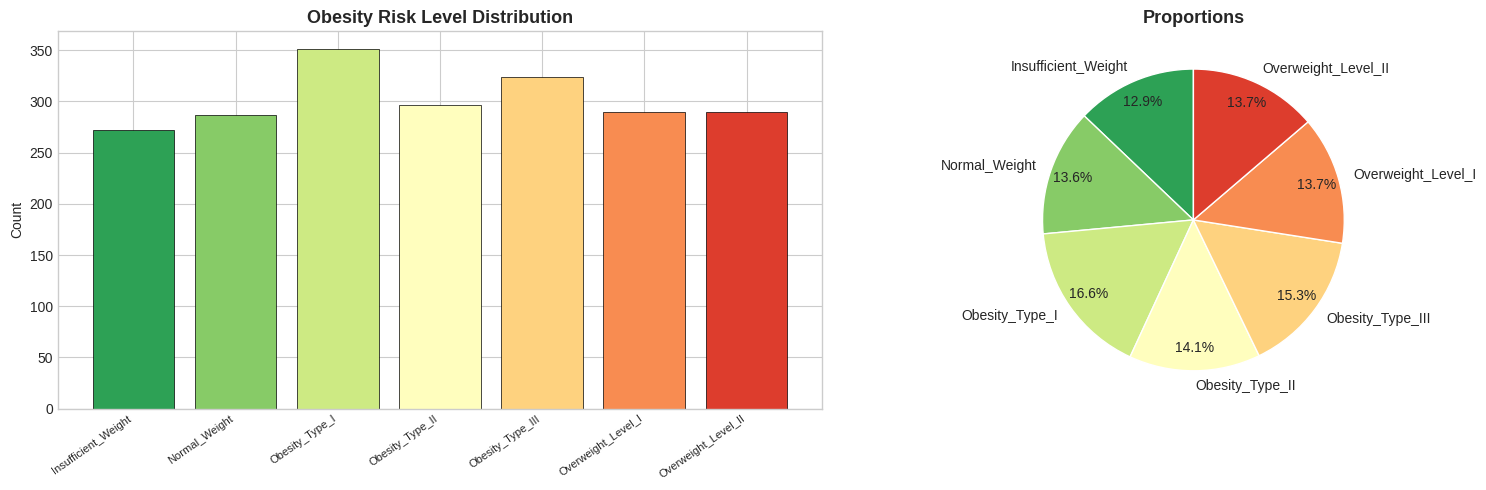

AU context: 67% of Australian adults are overweight or obese (AIHW 2022).
Obesity costs Australia ~$11.8B/year in healthcare and lost productivity.
National Obesity Strategy 2022-2032 targets population-level reduction.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
vc = df[target_col].value_counts().sort_index()
colors = sns.color_palette('RdYlGn_r', n_colors=n_classes)
axes[0].bar(range(len(vc)), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(target_labels, rotation=35, ha='right', fontsize=8)
axes[0].set_title('Obesity Risk Level Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[1].pie(vc.values, labels=target_labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[1].set_title('Proportions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: 67% of Australian adults are overweight or obese (AIHW 2022).")
print("Obesity costs Australia ~$11.8B/year in healthcare and lost productivity.")
print("National Obesity Strategy 2022-2032 targets population-level reduction.")


## 3. Exploratory Data Analysis

Numeric features (8): ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


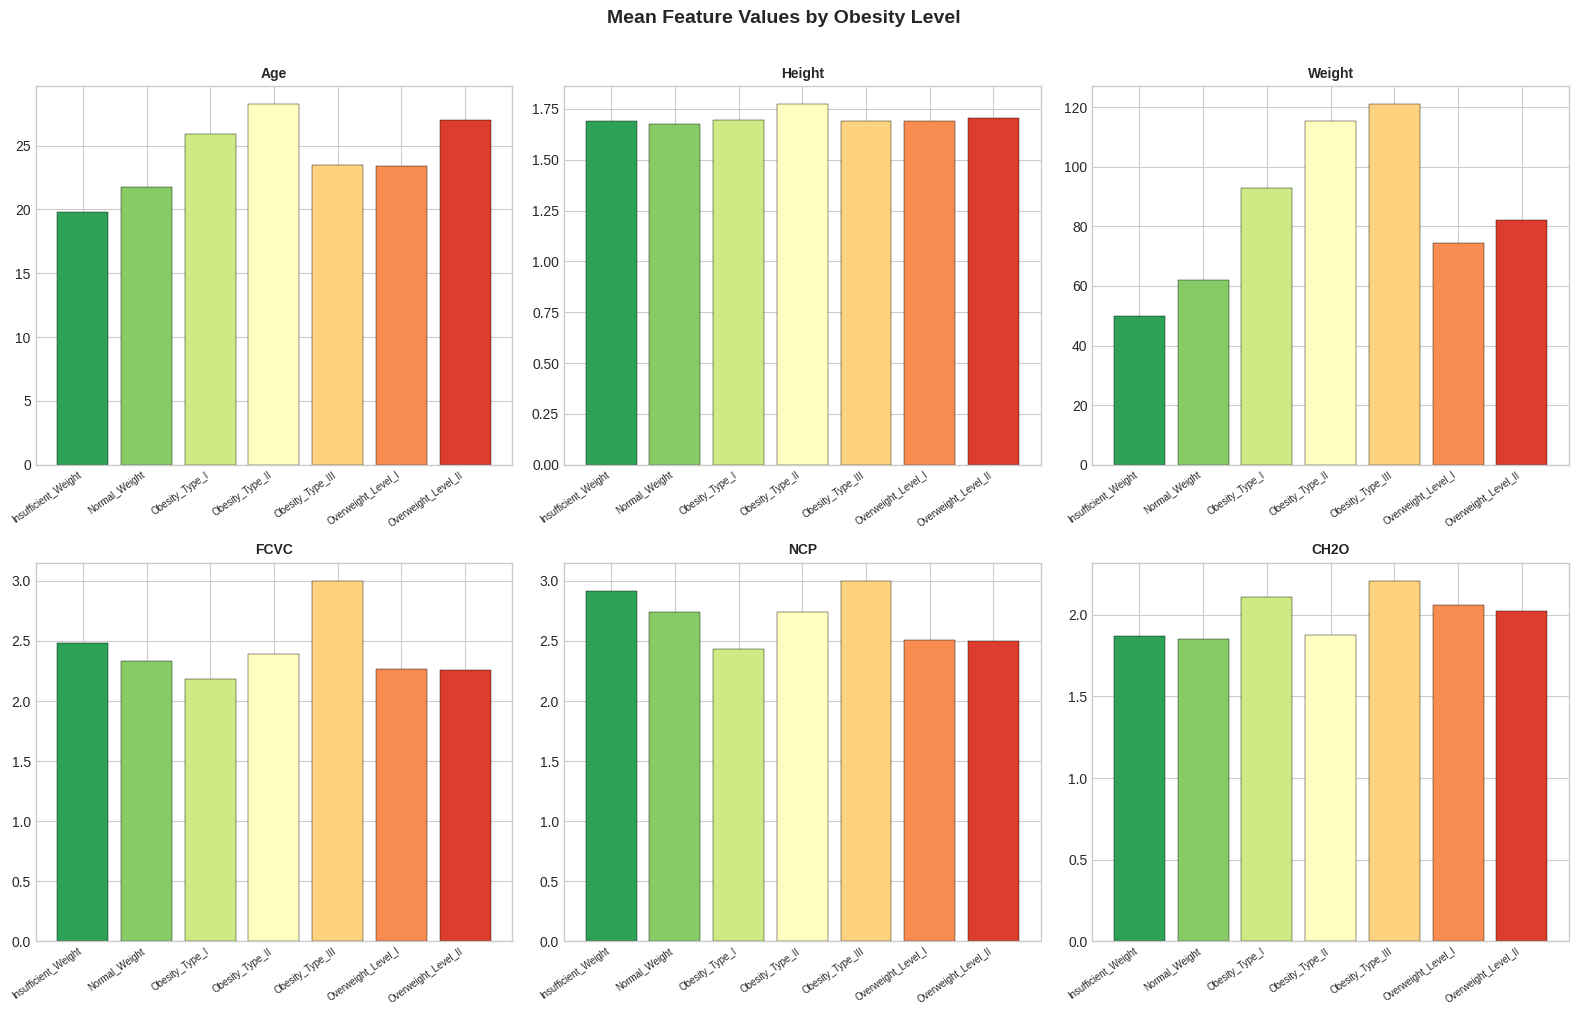

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['id', 'index']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols[:10]}")

plot_cols = numeric_cols[:6]
if len(plot_cols) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        means = df.groupby(target_col)[col].mean()
        axes[i].bar(range(len(means)), means.values, color=colors, edgecolor='black', linewidth=0.3)
        axes[i].set_xticks(range(len(means)))
        axes[i].set_xticklabels(target_labels, rotation=35, ha='right', fontsize=7)
        axes[i].set_title(col, fontsize=10, fontweight='bold')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Mean Feature Values by Obesity Level', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_by_obesity.png', dpi=150, bbox_inches='tight'); plt.show()


Categorical features: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


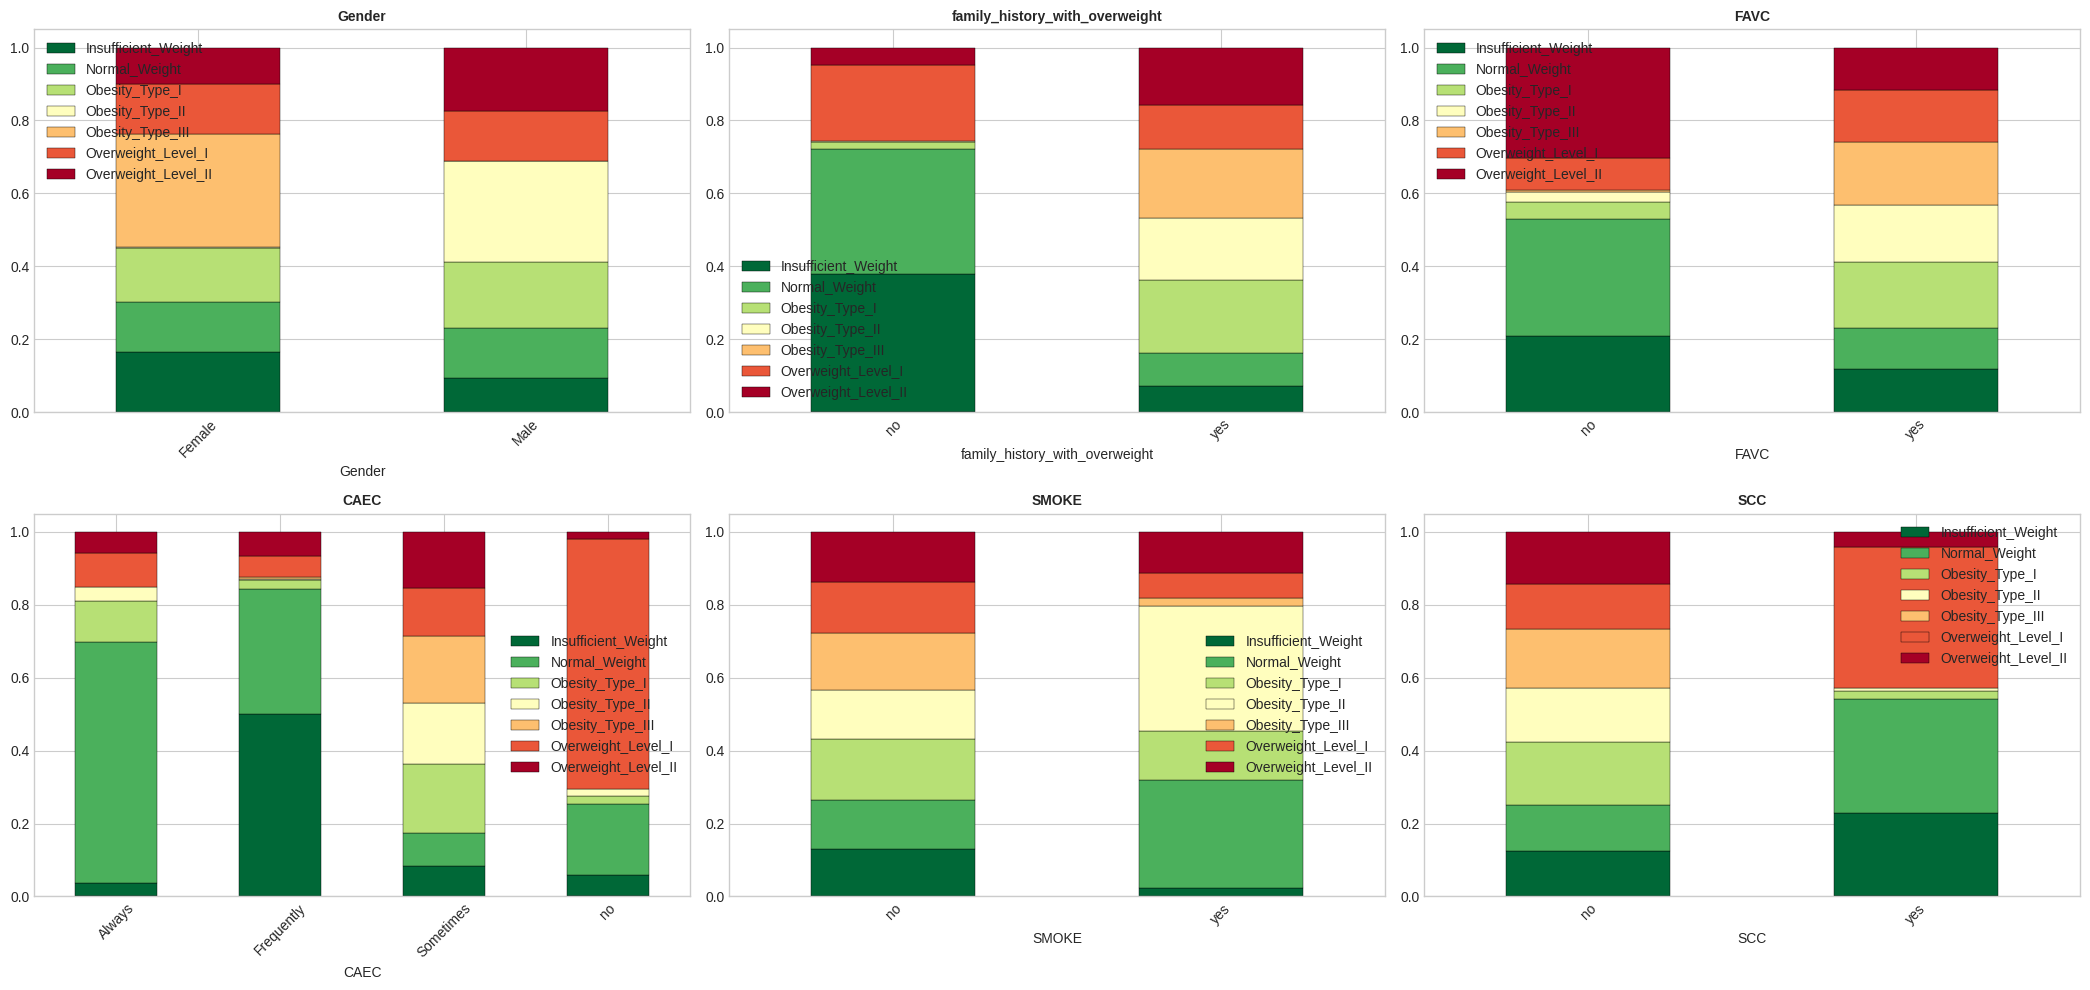

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 10]
print(f"Categorical features: {cat_cols}")

if len(cat_cols) > 0:
    plot_cats = cat_cols[:6]
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = max(1, (len(plot_cats) + n_cols_p - 1) // n_cols_p)
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray): axes = axes.flatten()
    else: axes = [axes]
    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.columns = target_labels[:len(ct.columns)]
        ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='RdYlGn_r', edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col}', fontsize=10, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


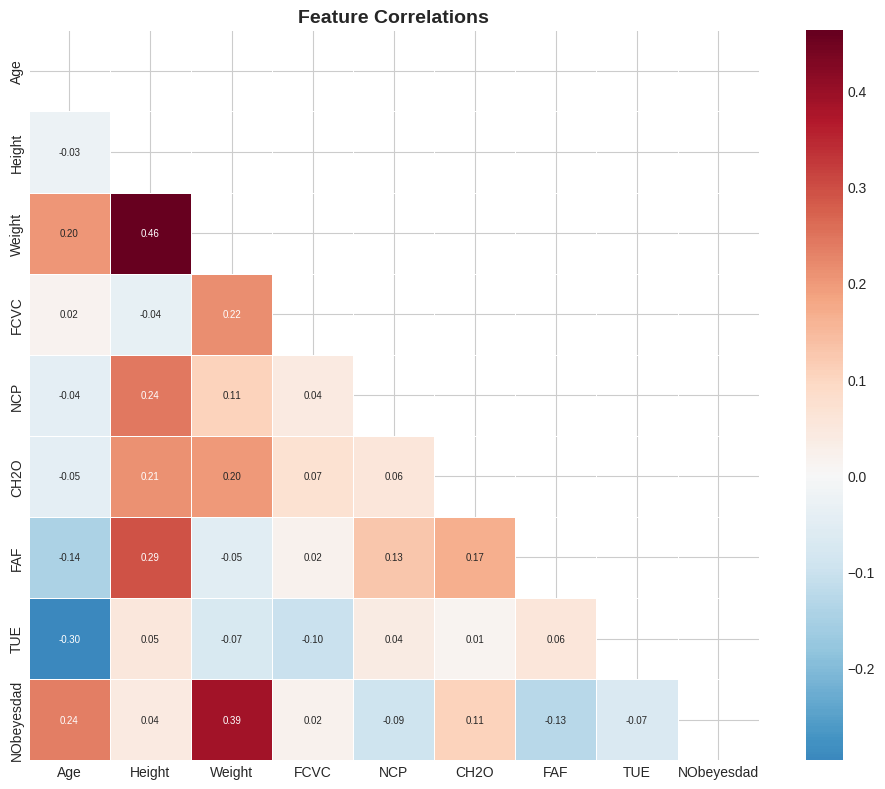

In [8]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols + [target_col]].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
    ax.set_title('Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()


## 4. Feature Engineering & Preprocessing

In [9]:
df_model = df.copy()

# Drop ID columns
drop_cols = [c for c in df_model.columns if c.lower() in ['id', 'index', 'unnamed: 0']]
if drop_cols:
    df_model.drop(columns=drop_cols, inplace=True)

# Encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

# Feature engineering
composites_added = []

# BMI calculation if height and weight available
height_cols = [c for c in X.columns if c.lower() in ['height', 'stature']]
weight_cols = [c for c in X.columns if c.lower() in ['weight']]
if height_cols and weight_cols:
    X['calculated_bmi'] = X[weight_cols[0]] / (X[height_cols[0]] ** 2)
    composites_added.append('calculated_bmi')
    print("Created 'calculated_bmi' (weight/height^2)")

# Physical activity deficit
activity_cols = [c for c in X.columns if any(kw in c.lower() for kw in ['faf', 'physical', 'activity'])]
if activity_cols:
    X['low_activity'] = (X[activity_cols[0]] < X[activity_cols[0]].median()).astype(int)
    composites_added.append('low_activity')
    print("Created 'low_activity'")

# Age risk
age_cols = [c for c in X.columns if c.lower() == 'age']
if age_cols:
    X['age_over_40'] = (X[age_cols[0]] >= 40).astype(int)
    composites_added.append('age_over_40')
    print("Created 'age_over_40'")

print(f"\nEngineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


  Encoded 'Gender': 2 classes
  Encoded 'family_history_with_overweight': 2 classes
  Encoded 'FAVC': 2 classes
  Encoded 'CAEC': 4 classes
  Encoded 'SMOKE': 2 classes
  Encoded 'SCC': 2 classes
  Encoded 'CALC': 4 classes
  Encoded 'MTRANS': 5 classes
Created 'calculated_bmi' (weight/height^2)
Created 'low_activity'
Created 'age_over_40'

Engineered: 3
Final feature count: 19


## 5. Model Training & Cross-Validation

In [10]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42, multi_class='multinomial'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_kappa = [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_arr[train_idx], y[train_idx])
        y_pred = model_clone.predict(X_arr[val_idx])
        fold_preds[val_idx] = y_pred
        acc = accuracy_score(y[val_idx], y_pred)
        f1 = f1_score(y[val_idx], y_pred, average='weighted')
        kappa = cohen_kappa_score(y[val_idx], y_pred)
        fold_acc.append(acc); fold_f1.append(f1); fold_kappa.append(kappa)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1(w)={f1:.4f}  Kappa={kappa:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'f1_mean': np.mean(fold_f1),
        'f1_std': np.std(fold_f1), 'kappa_mean': np.mean(fold_kappa),
        'time': elapsed, 'oof_preds': fold_preds}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  Kappa: {np.mean(fold_kappa):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.8821  F1(w)=0.8810  Kappa=0.8623
  Fold 2: Acc=0.8949  F1(w)=0.8943  Kappa=0.8773
  Fold 3: Acc=0.8777  F1(w)=0.8762  Kappa=0.8572
  -- Acc: 0.8849  F1: 0.8838  Kappa: 0.8656  Time: 5.47s

Training: Random Forest
  Fold 1: Acc=0.9858  F1(w)=0.9858  Kappa=0.9834
  Fold 2: Acc=0.9901  F1(w)=0.9901  Kappa=0.9884
  Fold 3: Acc=0.9886  F1(w)=0.9886  Kappa=0.9867
  -- Acc: 0.9882  F1: 0.9882  Kappa: 0.9862  Time: 1.22s

Training: XGBoost
  Fold 1: Acc=0.9759  F1(w)=0.9758  Kappa=0.9718
  Fold 2: Acc=0.9844  F1(w)=0.9844  Kappa=0.9817
  Fold 3: Acc=0.9815  F1(w)=0.9815  Kappa=0.9784
  -- Acc: 0.9806  F1: 0.9806  Kappa: 0.9773  Time: 0.85s

Training: LightGBM
  Fold 1: Acc=0.9801  F1(w)=0.9801  Kappa=0.9768
  Fold 2: Acc=0.9858  F1(w)=0.9858  Kappa=0.9834
  Fold 3: Acc=0.9815  F1(w)=0.9815  Kappa=0.9784
  -- Acc: 0.9825  F1: 0.9825  Kappa: 0.9795  Time: 2.37s


## 6. Model Comparison & Selection

In [12]:
summary_rows = [{'Model': mn, 'Accuracy': f"{res['accuracy_mean']:.4f}",
    'F1 (weighted)': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
    'Kappa': f"{res['kappa_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
    'sort_val': res['f1_mean']} for mn, res in results.items()]
summary_df = pd.DataFrame(summary_rows).sort_values('sort_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 90)
print(summary_df[['Model', 'Accuracy', 'F1 (weighted)', 'Kappa', 'Time']].to_string(index=False))
print("=" * 90)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model Accuracy     F1 (weighted)  Kappa  Time
      Random Forest   0.9882 0.9882 +/- 0.0018 0.9862 1.22s
           LightGBM   0.9825 0.9825 +/- 0.0024 0.9795 2.37s
            XGBoost   0.9806 0.9806 +/- 0.0035 0.9773 0.85s
Logistic Regression   0.8849 0.8838 +/- 0.0076 0.8656 5.47s

Best model: Random Forest


## 7. Error Analysis

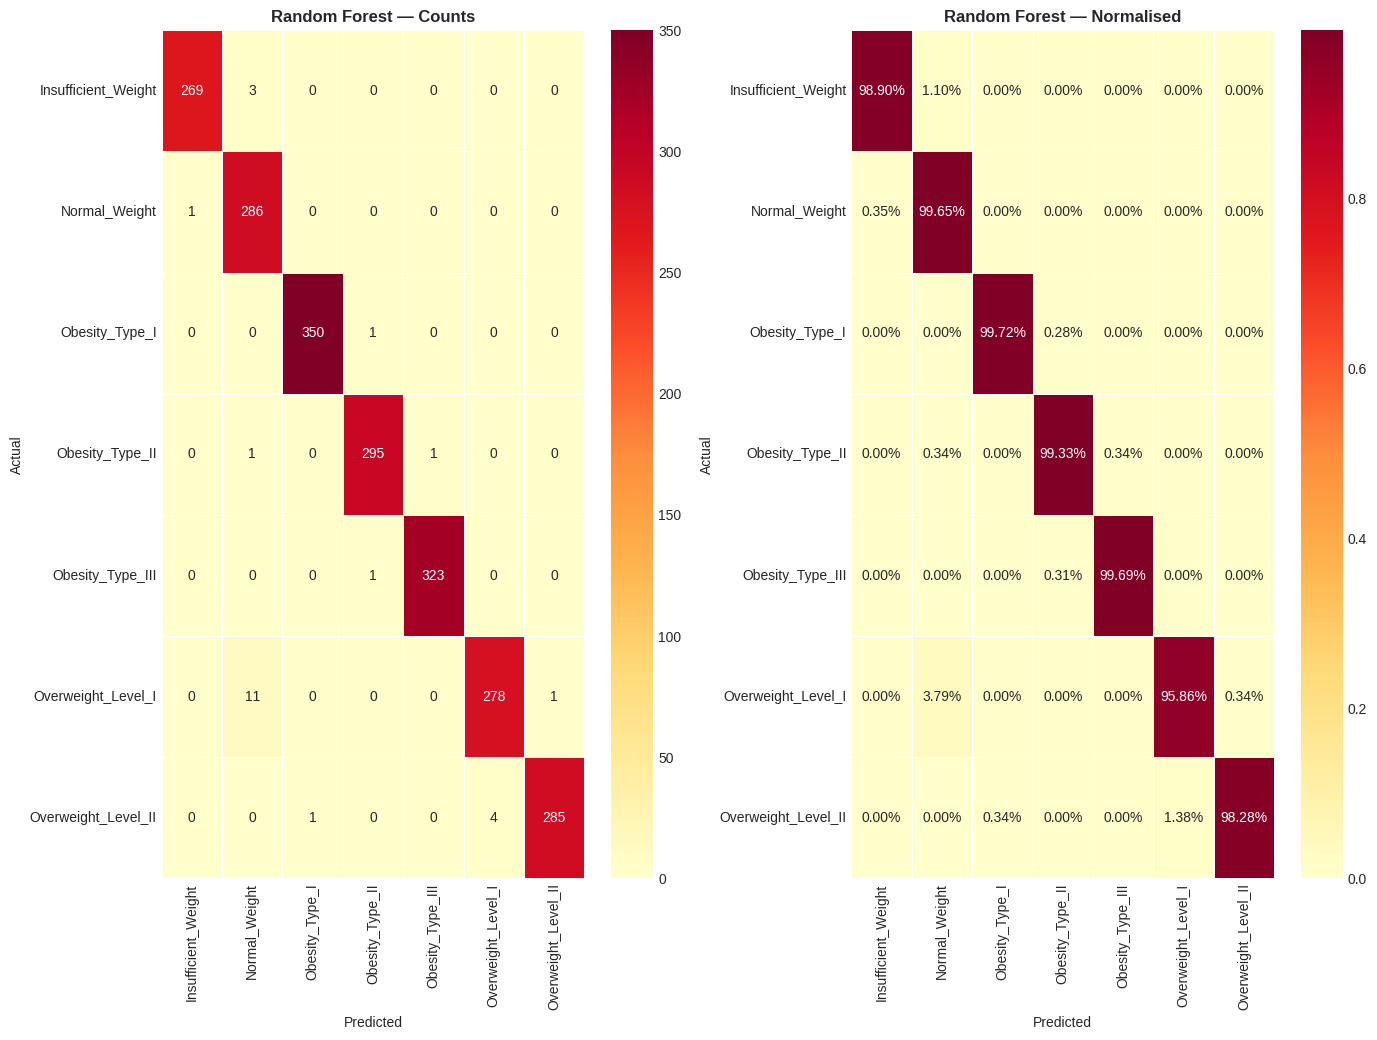


                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.99      0.99       272
      Normal_Weight       0.95      1.00      0.97       287
     Obesity_Type_I       1.00      1.00      1.00       351
    Obesity_Type_II       0.99      0.99      0.99       297
   Obesity_Type_III       1.00      1.00      1.00       324
 Overweight_Level_I       0.99      0.96      0.97       290
Overweight_Level_II       1.00      0.98      0.99       290

           accuracy                           0.99      2111
          macro avg       0.99      0.99      0.99      2111
       weighted avg       0.99      0.99      0.99      2111



In [13]:
best_preds = results[best_model_name]['oof_preds']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(max(12, n_classes*2), max(6, n_classes*1.5)))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', xticklabels=target_labels, yticklabels=target_labels,
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd', xticklabels=target_labels, yticklabels=target_labels,
            ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=target_labels)}")


## 8. Feature Importance & Policy Insights

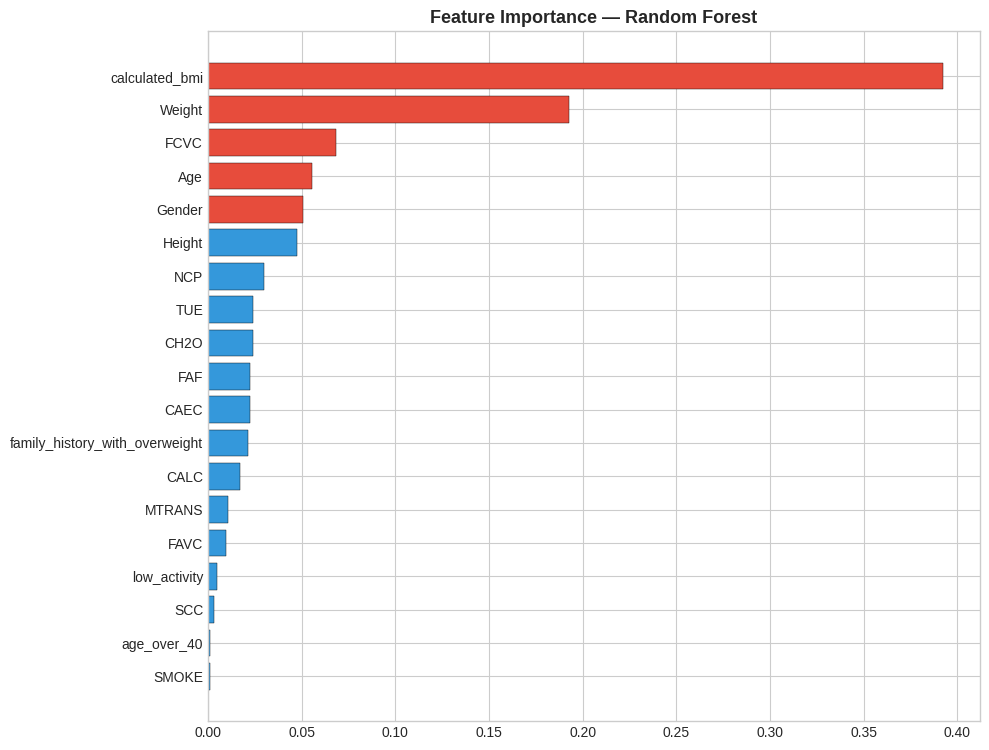

TOP 5 OBESITY RISK PREDICTORS
  calculated_bmi             0.3925
  Weight                     0.1927
  FCVC                       0.0686
  Age                        0.0555
  Gender                     0.0507

Policy insight: Weight, eating habits, and physical activity are key modifiable factors.
Family history is non-modifiable but important for targeted screening.


In [14]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['f1_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 OBESITY RISK PREDICTORS")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:25s}  {row['Importance']:.4f}")
    print("\nPolicy insight: Weight, eating habits, and physical activity are key modifiable factors.")
    print("Family history is non-modifiable but important for targeted screening.")


## 9. Deployment Readiness & Production Considerations

In [15]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  Accuracy:             {best_res['accuracy_mean']:.4f}")
print(f"  F1 (weighted):        {best_res['f1_mean']:.4f}")
print(f"  Cohen's Kappa:        {best_res['kappa_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  Obesity classes:      {n_classes}")
print(f"  CV strategy:          3-fold Stratified")
print("=" * 60)
checks = {
    'Accuracy > 0.70': best_res['accuracy_mean'] > 0.70,
    'F1 > 0.70': best_res['f1_mean'] > 0.70,
    'Kappa > 0.60': best_res['kappa_mean'] > 0.60,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Feature importance available': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Random Forest
  Accuracy:             0.9882
  F1 (weighted):        0.9882
  Cohen's Kappa:        0.9862
  Training time:        1.2s
  Feature count:        19
  Dataset rows:         2,111
  Obesity classes:      7
  CV strategy:          3-fold Stratified

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] Accuracy > 0.70
  [pass] F1 > 0.70
  [pass] Kappa > 0.60
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Feature importance available
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [16]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: GP health assessments, My Health Record, ABS Health Survey
   Ingestion: HL7 FHIR API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (BMI, diet, activity, family history)
   Schedule: At health assessment + quarterly population analytics

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time at GP health check (<200ms)
   Output: Obesity risk tier + modifiable risk factors + action plan
   Batch: PHN population obesity risk stratification by LGA

3. INTEGRATION POINTS
   GP desktop: Obesity risk alert in clinical software
   Medicare: Trigger CDM items for weight management plans
   Allied health: Auto-referral to dietitian/exercise physiologist
   AIHW: Population surveillance data contribution
   Health promotion: Targeted community program delivery

4. GOVERNANCE
   Sensitivity: Obesity is stigmatised — model output must be clinical, not judgmental
   Equity: Monitor across Indigenous, CALD, rural/remote, socioeconomic groups
   Privacy: Health data under Privacy Act 1988
   Guidelines: Alignment with NHMRC dietary and activity guidelines
   Ethics: Focus on health outcomes, not appearance

5. MONITORING & RETRAINING
   Drift: PSI on biometric/lifestyle features annually
   Performance: Against clinical BMI measurements
   Retraining: Annual with updated ABS Health Survey data
   Trends: Adjust for population-level obesity trend changes
   Policy: Recalibrate when National Obesity Strategy updates

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: GP health assessments, My Health Record, ABS Health Survey
   Ingestion: HL7 FHIR API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (BMI, diet, activity, family history)
   Schedule: At health assessment + quarterly population analytics

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time at GP health check (<200ms)
   Output: Obesity risk tier + modifiable risk factors + action plan
   Batch: PHN population obesity risk stratification by LGA

3. INTEGRATION POINTS
   GP desktop: Obesity risk alert in clinical software
   Medicare: Trigger CDM items for weight management plans
   Allied health: Auto-referral to dietitian/exercise physiologist
   AIHW: Population surveillance data contribution
   Health promotion: Targeted community program delivery

4. GOVERNANCE
   Sensitivity: Obesity is stigmatised — model output must be clinical, not judgmental
   Equity: Monito